In [1]:
import os
import glob
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import random
from datetime import datetime, timedelta
from dateutil.relativedelta import relativedelta
import pprint
import pyspark
import pyspark.sql.functions as F

from pyspark.sql.functions import col
from pyspark.sql.types import StringType, IntegerType, FloatType, DateType

import utils.data_processing_bronze_table
import utils.data_processing_silver_lms_table
import utils.data_processing_silver_feature_table
import utils.data_processing_gold_lms_table
import utils.data_processing_gold_feature_table


## set up pyspark session

In [2]:
# Initialize SparkSession
spark = pyspark.sql.SparkSession.builder \
    .appName("dev") \
    .master("local[*]") \
    .getOrCreate()

# Set log level to ERROR to hide warnings
spark.sparkContext.setLogLevel("ERROR")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/05/19 20:33:59 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


## set up config

In [3]:
# set up config
snapshot_date_str = "2023-01-01"

start_date_str = "2023-01-01"
end_date_str = "2024-12-01"

In [4]:
# generate list of dates to process
def generate_first_of_month_dates(start_date_str, end_date_str):
    # Convert the date strings to datetime objects
    start_date = datetime.strptime(start_date_str, "%Y-%m-%d")
    end_date = datetime.strptime(end_date_str, "%Y-%m-%d")
    
    # List to store the first of month dates
    first_of_month_dates = []

    # Start from the first of the month of the start_date
    current_date = datetime(start_date.year, start_date.month, 1)

    while current_date <= end_date:
        # Append the date in yyyy-mm-dd format
        first_of_month_dates.append(current_date.strftime("%Y-%m-%d"))
        
        # Move to the first of the next month
        if current_date.month == 12:
            current_date = datetime(current_date.year + 1, 1, 1)
        else:
            current_date = datetime(current_date.year, current_date.month + 1, 1)

    return first_of_month_dates

dates_str_lst = generate_first_of_month_dates(start_date_str, end_date_str)
dates_str_lst

['2023-01-01',
 '2023-02-01',
 '2023-03-01',
 '2023-04-01',
 '2023-05-01',
 '2023-06-01',
 '2023-07-01',
 '2023-08-01',
 '2023-09-01',
 '2023-10-01',
 '2023-11-01',
 '2023-12-01',
 '2024-01-01',
 '2024-02-01',
 '2024-03-01',
 '2024-04-01',
 '2024-05-01',
 '2024-06-01',
 '2024-07-01',
 '2024-08-01',
 '2024-09-01',
 '2024-10-01',
 '2024-11-01',
 '2024-12-01']

## Build Bronze Table

In [5]:
# create bronze lms datalake
bronze_lms_directory = "datamart/bronze/lms/"

if not os.path.exists(bronze_lms_directory):
    os.makedirs(bronze_lms_directory)

In [6]:
# run bronze backfill
for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_table(date_str, "data/lms_loan_daily.csv", bronze_lms_directory, "loan_daily", spark)


2023-01-01row count: 530
saved to: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv
2023-02-01row count: 1031
saved to: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv
2023-03-01row count: 1537
saved to: datamart/bronze/lms/bronze_loan_daily_2023_03_01.csv
2023-04-01row count: 2047
saved to: datamart/bronze/lms/bronze_loan_daily_2023_04_01.csv
2023-05-01row count: 2568
saved to: datamart/bronze/lms/bronze_loan_daily_2023_05_01.csv
2023-06-01row count: 3085
saved to: datamart/bronze/lms/bronze_loan_daily_2023_06_01.csv
2023-07-01row count: 3556
saved to: datamart/bronze/lms/bronze_loan_daily_2023_07_01.csv
2023-08-01row count: 4037
saved to: datamart/bronze/lms/bronze_loan_daily_2023_08_01.csv
2023-09-01row count: 4491
saved to: datamart/bronze/lms/bronze_loan_daily_2023_09_01.csv
2023-10-01row count: 4978
saved to: datamart/bronze/lms/bronze_loan_daily_2023_10_01.csv
2023-11-01row count: 5469
saved to: datamart/bronze/lms/bronze_loan_daily_2023_11_01.csv
2023-12-01row count: 5

In [7]:
# inspect output
utils.data_processing_bronze_table.process_bronze_table(date_str, "data/lms_loan_daily.csv", bronze_lms_directory, "loan_daily", spark).toPandas()

2024-12-01row count: 5531
saved to: datamart/bronze/lms/bronze_loan_daily_2024_12_01.csv


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000,1000.0,1000.0,0.0,1000.0,2024-12-01
1,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,8,10000,1000.0,0.0,6000.0,8000.0,2024-12-01
2,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2024-12-01
3,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,0,10000,0.0,0.0,0.0,10000.0,2024-12-01
4,CUS_0x1048_2024_02_01,CUS_0x1048,2024-02-01,10,10,10000,1000.0,0.0,9000.0,9000.0,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...
5526,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,8,10000,1000.0,1000.0,0.0,2000.0,2024-12-01
5527,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,6,10000,1000.0,1000.0,0.0,4000.0,2024-12-01
5528,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,0,10000,0.0,0.0,0.0,10000.0,2024-12-01
5529,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,2,10000,1000.0,1000.0,0.0,8000.0,2024-12-01


In [8]:
# create bronze clickstream datalake
bronze_clickstream_directory = "datamart/bronze/clickstream/"

if not os.path.exists(bronze_clickstream_directory):
    os.makedirs(bronze_clickstream_directory)
    
# run bronze backfill
for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_table(date_str, "data/feature_clickstream.csv", bronze_clickstream_directory, "clickstream", spark)

# inspect output
utils.data_processing_bronze_table.process_bronze_table(date_str, "data/feature_clickstream.csv", bronze_clickstream_directory, "clickstream", spark).toPandas()

2023-01-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_01_01.csv
2023-02-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_02_01.csv
2023-03-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_03_01.csv
2023-04-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_04_01.csv
2023-05-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_05_01.csv
2023-06-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_06_01.csv
2023-07-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_07_01.csv
2023-08-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_08_01.csv
2023-09-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_09_01.csv
2023-10-01row count: 8974
saved to: datamart/bronze/clickstream/bronze_clickstream_2023_10_01.csv
2023-11-01row count:

,fe_1,fe_2,fe_3,fe_4,fe_5,fe_6,fe_7,fe_8,fe_9,fe_10,...,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20,Customer_ID,snapshot_date
0,145,189,109,134,196,-37,101,82,111,24,...,65,249,200,185,-83,-18,-76,30,CUS_0x1037,2024-12-01
1,40,184,187,75,192,146,38,109,353,141,...,-14,193,125,117,215,91,33,255,CUS_0x1069,2024-12-01
2,98,121,180,200,95,48,59,194,76,84,...,167,101,92,185,98,68,-60,116,CUS_0x114a,2024-12-01
3,85,96,19,47,30,39,-32,210,-81,206,...,143,94,139,237,78,187,77,33,CUS_0x1184,2024-12-01
4,98,45,155,56,112,47,52,138,153,225,...,-43,142,121,10,189,110,264,241,CUS_0x1297,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8969,414,22,72,57,142,192,11,139,24,63,...,179,91,20,189,-35,-19,15,66,CUS_0xdf6,2024-12-01
8970,116,-124,-108,212,-21,227,146,112,186,-65,...,38,226,319,98,9,152,17,14,CUS_0xe23,2024-12-01
8971,237,-3,-49,375,144,41,-170,324,19,266,...,7,102,64,191,124,220,231,75,CUS_0xe4e,2024-12-01
8972,5,67,211,83,207,-41,325,14,-18,41,...,109,266,28,157,131,116,101,131,CUS_0xedd,2024-12-01


In [9]:
# create bronze attributes datalake
bronze_attributes_directory = "datamart/bronze/attributes/"

if not os.path.exists(bronze_attributes_directory):
    os.makedirs(bronze_attributes_directory)
    
# run bronze backfill
for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_table(date_str, "data/features_attributes.csv", bronze_attributes_directory, "attributes", spark)

# inspect output
utils.data_processing_bronze_table.process_bronze_table(date_str, "data/features_attributes.csv", bronze_attributes_directory, "attributes", spark).toPandas()

2023-01-01row count: 530
saved to: datamart/bronze/attributes/bronze_attributes_2023_01_01.csv
2023-02-01row count: 501
saved to: datamart/bronze/attributes/bronze_attributes_2023_02_01.csv
2023-03-01row count: 506
saved to: datamart/bronze/attributes/bronze_attributes_2023_03_01.csv
2023-04-01row count: 510
saved to: datamart/bronze/attributes/bronze_attributes_2023_04_01.csv
2023-05-01row count: 521
saved to: datamart/bronze/attributes/bronze_attributes_2023_05_01.csv
2023-06-01row count: 517
saved to: datamart/bronze/attributes/bronze_attributes_2023_06_01.csv
2023-07-01row count: 471
saved to: datamart/bronze/attributes/bronze_attributes_2023_07_01.csv
2023-08-01row count: 481
saved to: datamart/bronze/attributes/bronze_attributes_2023_08_01.csv
2023-09-01row count: 454
saved to: datamart/bronze/attributes/bronze_attributes_2023_09_01.csv
2023-10-01row count: 487
saved to: datamart/bronze/attributes/bronze_attributes_2023_10_01.csv
2023-11-01row count: 491
saved to: datamart/bronze

,Customer_ID,Name,Age,SSN,Occupation,snapshot_date
0,CUS_0x103e,Tim Kellyf,40,155-72-8070,Scientist,2024-12-01
1,CUS_0x1195,Alexk,31,822-48-3629,Manager,2024-12-01
2,CUS_0x1197,Nayako,28,799-23-8283,_______,2024-12-01
3,CUS_0x11e2,Valetkevitchr,34,809-04-1419,Musician,2024-12-01
4,CUS_0x11ec,William Schombergh,34,417-74-2163,Journalist,2024-12-01
...,...,...,...,...,...,...
510,CUS_0xe6c,Doris Frankelh,26,172-24-1577,Entrepreneur,2024-12-01
511,CUS_0xe99,Moone,48,164-90-3178,Mechanic,2024-12-01
512,CUS_0xf55,Tarmo Virkip,39,025-54-8593,Entrepreneur,2024-12-01
513,CUS_0xfd1,Frewy,32,389-55-6408,Architect,2024-12-01


In [10]:
# create bronze financials datalake
bronze_financials_directory = "datamart/bronze/financials/"

if not os.path.exists(bronze_financials_directory):
    os.makedirs(bronze_financials_directory)
    
# run bronze backfill
for date_str in dates_str_lst:
    utils.data_processing_bronze_table.process_bronze_table(date_str, "data/features_financials.csv", bronze_financials_directory, "financials", spark)

# inspect output
utils.data_processing_bronze_table.process_bronze_table(date_str, "data/features_financials.csv", bronze_financials_directory, "financials", spark).toPandas()

2023-01-01row count: 530
saved to: datamart/bronze/financials/bronze_financials_2023_01_01.csv
2023-02-01row count: 501
saved to: datamart/bronze/financials/bronze_financials_2023_02_01.csv
2023-03-01row count: 506
saved to: datamart/bronze/financials/bronze_financials_2023_03_01.csv
2023-04-01row count: 510
saved to: datamart/bronze/financials/bronze_financials_2023_04_01.csv
2023-05-01row count: 521
saved to: datamart/bronze/financials/bronze_financials_2023_05_01.csv
2023-06-01row count: 517
saved to: datamart/bronze/financials/bronze_financials_2023_06_01.csv
2023-07-01row count: 471
saved to: datamart/bronze/financials/bronze_financials_2023_07_01.csv
2023-08-01row count: 481
saved to: datamart/bronze/financials/bronze_financials_2023_08_01.csv
2023-09-01row count: 454
saved to: datamart/bronze/financials/bronze_financials_2023_09_01.csv
2023-10-01row count: 487
saved to: datamart/bronze/financials/bronze_financials_2023_10_01.csv
2023-11-01row count: 491
saved to: datamart/bronze

,Customer_ID,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Type_of_Loan,Delay_from_due_date,Num_of_Delayed_Payment,...,Credit_Mix,Outstanding_Debt,Credit_Utilization_Ratio,Credit_History_Age,Payment_of_Min_Amount,Total_EMI_per_month,Amount_invested_monthly,Payment_Behaviour,Monthly_Balance,snapshot_date
0,CUS_0x103e,98690.8,8262.233333,4,6,9,1_,Student Loan,6,17,...,Good,706.96,26.860663,26 Years and 11 Months,No,55.004408,913.4813186573292,Low_spent_Small_value_payments,147.7376071067124,2024-12-01
1,CUS_0x1195,30429.91,2808.825833,4,6,16,2,"Auto Loan, and Auto Loan",22,17,...,Standard,362.48,33.349050,28 Years and 11 Months,No,29.914076,82.87878577514347,Low_spent_Large_value_payments,438.08972109416084,2024-12-01
2,CUS_0x1197,92300.01,7437.667500,2,4,11,3,"Credit-Builder Loan, Not Specified, and Credit...",27,9,...,_,755.17_,26.989787,18 Years and 11 Months,Yes,49236.000000,220.8621525417414,Low_spent_Large_value_payments,581.1567885447394,2024-12-01
3,CUS_0x11e2,44986.55,3689.879167,6,5,11,1,Credit-Builder Loan,0,4,...,Good,753.21,25.586286,20 Years and 0 Months,No,23.267135,43.20363344633164,High_spent_Large_value_payments,542.5171477430948,2024-12-01
4,CUS_0x11ec,14867.69,1005.974167,9,9,18,6,"Debt Consolidation Loan, Student Loan, Persona...",39,15,...,Standard,2344.06,24.344388,17 Years and 2 Months,Yes,55.459604,100.14574834721886,Low_spent_Medium_value_payments,224.99206407779144,2024-12-01
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,CUS_0xe6c,125597.52,9367.500187,1,3,12,4,"Debt Consolidation Loan, Not Specified, Studen...",2,9,...,Good,1294.94,30.324257,30 Years and 5 Months,NM,1278.186251,964.5381161830327,Low_spent_Medium_value_payments,763.3982127892344,2024-12-01
511,CUS_0xe99,45461.54,3917.461667,6,3,5,2,"Credit-Builder Loan, and Payday Loan",20,9,...,Standard,647.24,27.264685,16 Years and 9 Months,No,69.318349,42.941001590068666,High_spent_Large_value_payments,519.4868162135749,2024-12-01
512,CUS_0xf55,78443.48_,6358.956667,7,5,23,4,"Personal Loan, Home Equity Loan, Mortgage Loan...",39,19,...,Bad,1527.77,24.704429,15 Years and 10 Months,NM,177.387563,528.7469053018515,Low_spent_Medium_value_payments,209.76119880079318,2024-12-01
513,CUS_0xfd1,78666.56999999999,6485.547500,3,4,17,4,"Not Specified, Personal Loan, Home Equity Loan...",29,10,...,Standard,1498.7,37.831762,22 Years and 5 Months,No,247.851145,252.3461368272953,High_spent_Small_value_payments,408.35746850506007,2024-12-01


## Build Silver Table

In [11]:
# create silver lms datalake
silver_loan_daily_directory = "datamart/silver/loan_daily/"

if not os.path.exists(silver_loan_daily_directory):
    os.makedirs(silver_loan_daily_directory)

In [12]:
# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_lms_table.process_silver_lms_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark)


loaded from: datamart/bronze/lms/bronze_loan_daily_2023_01_01.csv row count: 530


saved to: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_02_01.csv row count: 1031
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_03_01.csv row count: 1537
saved to: datamart/silver/loan_daily/silver_loan_daily_2023_03_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_04_01.csv row count: 2047


saved to: datamart/silver/loan_daily/silver_loan_daily_2023_04_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_05_01.csv row count: 2568


saved to: datamart/silver/loan_daily/silver_loan_daily_2023_05_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_06_01.csv row count: 3085


saved to: datamart/silver/loan_daily/silver_loan_daily_2023_06_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2023_07_01.csv row count: 3556


...

saved to: datamart/silver/loan_daily/silver_loan_daily_2024_07_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2024_08_01.csv row count: 5531


saved to: datamart/silver/loan_daily/silver_loan_daily_2024_08_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2024_09_01.csv row count: 5537


saved to: datamart/silver/loan_daily/silver_loan_daily_2024_09_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2024_10_01.csv row count: 5502


saved to: datamart/silver/loan_daily/silver_loan_daily_2024_10_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2024_11_01.csv row count: 5501


saved to: datamart/silver/loan_daily/silver_loan_daily_2024_11_01.parquet
loaded from: datamart/bronze/lms/bronze_loan_daily_2024_12_01.csv row count: 5531
saved to: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet


In [13]:
utils.data_processing_silver_lms_table.process_silver_lms_table(date_str, bronze_lms_directory, silver_loan_daily_directory, spark).toPandas()

loaded from: datamart/bronze/lms/bronze_loan_daily_2024_12_01.csv row count: 5531


saved to: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet


,loan_id,Customer_ID,loan_start_date,tenure,installment_num,loan_amt,due_amt,paid_amt,overdue_amt,balance,snapshot_date,mob,installments_missed,first_missed_date,dpd
0,CUS_0x100b_2024_03_01,CUS_0x100b,2024-03-01,10,9,10000.0,1000.0,1000.0,0.0,1000.0,2024-12-01,9,0,None,0
1,CUS_0x102e_2024_04_01,CUS_0x102e,2024-04-01,10,8,10000.0,1000.0,0.0,6000.0,8000.0,2024-12-01,8,6,2024-06-01,183
2,CUS_0x1038_2024_10_01,CUS_0x1038,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0
3,CUS_0x103e_2024_12_01,CUS_0x103e,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
4,CUS_0x1048_2024_02_01,CUS_0x1048,2024-02-01,10,10,10000.0,1000.0,0.0,9000.0,9000.0,2024-12-01,10,9,2024-03-01,275
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
5526,CUS_0xfe3_2024_04_01,CUS_0xfe3,2024-04-01,10,8,10000.0,1000.0,1000.0,0.0,2000.0,2024-12-01,8,0,None,0
5527,CUS_0xff3_2024_06_01,CUS_0xff3,2024-06-01,10,6,10000.0,1000.0,1000.0,0.0,4000.0,2024-12-01,6,0,None,0
5528,CUS_0xff4_2024_12_01,CUS_0xff4,2024-12-01,10,0,10000.0,0.0,0.0,0.0,10000.0,2024-12-01,0,0,None,0
5529,CUS_0xff6_2024_10_01,CUS_0xff6,2024-10-01,10,2,10000.0,1000.0,1000.0,0.0,8000.0,2024-12-01,2,0,None,0


In [14]:
# create silver feature datalake
silver_features_directory = "datamart/silver/features/"

if not os.path.exists(silver_features_directory):
    os.makedirs(silver_features_directory)

# run silver backfill
for date_str in dates_str_lst:
    utils.data_processing_silver_feature_table.process_silver_feature_table(date_str, bronze_attributes_directory, bronze_financials_directory, 
                                                                            bronze_clickstream_directory, silver_features_directory, spark)

utils.data_processing_silver_feature_table.process_silver_feature_table(date_str, bronze_attributes_directory, bronze_financials_directory, 
                                                                        bronze_clickstream_directory, silver_features_directory, spark).toPandas()

loaded from: datamart/bronze/attributes/bronze_attributes_2023_01_01.csv row count: 530
loaded from: datamart/bronze/financials/bronze_financials_2023_01_01.csv row count: 530
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_01_01.csv row count: 8974
joined row count: 530


saved to: datamart/silver/features/silver_feature_store_2023_01_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2023_02_01.csv row count: 501
loaded from: datamart/bronze/financials/bronze_financials_2023_02_01.csv row count: 501
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_02_01.csv row count: 8974
joined row count: 501


saved to: datamart/silver/features/silver_feature_store_2023_02_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2023_03_01.csv row count: 506
loaded from: datamart/bronze/financials/bronze_financials_2023_03_01.csv row count: 506
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_03_01.csv row count: 8974
joined row count: 506


saved to: datamart/silver/features/silver_feature_store_2023_03_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2023_04_01.csv row count: 510
loaded from: datamart/bronze/financials/bronze_financials_2023_04_01.csv row count: 510
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_04_01.csv row count: 8974
joined row count: 510
saved to: datamart/silver/features/silver_feature_store_2023_04_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2023_05_01.csv row count: 521
loaded from: datamart/bronze/financials/bronze_financials_2023_05_01.csv row count: 521
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_05_01.csv row count: 8974
joined row count: 521


saved to: datamart/silver/features/silver_feature_store_2023_05_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2023_06_01.csv row count: 517
loaded from: datamart/bronze/financials/bronze_financials_2023_06_01.csv row count: 517
loaded from: datamart/bronze/clickstream/bronze_clickstream_2023_06_01.csv row count: 8974
joined row count: 517


...

saved to: datamart/silver/features/silver_feature_store_2024_04_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2024_05_01.csv row count: 491
loaded from: datamart/bronze/financials/bronze_financials_2024_05_01.csv row count: 491
loaded from: datamart/bronze/clickstream/bronze_clickstream_2024_05_01.csv row count: 8974
joined row count: 491
saved to: datamart/silver/features/silver_feature_store_2024_05_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2024_06_01.csv row count: 498
loaded from: datamart/bronze/financials/bronze_financials_2024_06_01.csv row count: 498
loaded from: datamart/bronze/clickstream/bronze_clickstream_2024_06_01.csv row count: 8974
joined row count: 498
saved to: datamart/silver/features/silver_feature_store_2024_06_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2024_07_01.csv row count: 505
loaded from: datamart/bronze/financials/bronze_financials_2024_07_01.csv row count: 505
loaded from: datamart

saved to: datamart/silver/features/silver_feature_store_2024_09_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2024_10_01.csv row count: 456
loaded from: datamart/bronze/financials/bronze_financials_2024_10_01.csv row count: 456
loaded from: datamart/bronze/clickstream/bronze_clickstream_2024_10_01.csv row count: 8974
joined row count: 456


saved to: datamart/silver/features/silver_feature_store_2024_10_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2024_11_01.csv row count: 488
loaded from: datamart/bronze/financials/bronze_financials_2024_11_01.csv row count: 488
loaded from: datamart/bronze/clickstream/bronze_clickstream_2024_11_01.csv row count: 8974
joined row count: 488
saved to: datamart/silver/features/silver_feature_store_2024_11_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2024_12_01.csv row count: 515
loaded from: datamart/bronze/financials/bronze_financials_2024_12_01.csv row count: 515
loaded from: datamart/bronze/clickstream/bronze_clickstream_2024_12_01.csv row count: 8974
joined row count: 515
saved to: datamart/silver/features/silver_feature_store_2024_12_01.parquet
loaded from: datamart/bronze/attributes/bronze_attributes_2024_12_01.csv row count: 515
loaded from: datamart/bronze/financials/bronze_financials_2024_12_01.csv row count: 515
loaded from: datamart

saved to: datamart/silver/features/silver_feature_store_2024_12_01.parquet


,Customer_ID,snapshot_date,Age,Occupation,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,...,fe_11,fe_12,fe_13,fe_14,fe_15,fe_16,fe_17,fe_18,fe_19,fe_20
0,CUS_0x103e,2024-12-01,40.0,Scientist,98690.796875,8262.233398,4,6,9.0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CUS_0x1195,2024-12-01,31.0,Manager,30429.910156,2808.825928,4,6,16.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CUS_0x1197,2024-12-01,28.0,_______,92300.007812,7437.667480,2,4,11.0,3.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CUS_0x11e2,2024-12-01,34.0,Musician,44986.550781,3689.879150,6,5,11.0,1.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CUS_0x11ec,2024-12-01,34.0,Journalist,14867.690430,1005.974182,9,9,18.0,6.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
510,CUS_0xe6c,2024-12-01,26.0,Entrepreneur,125597.523438,9367.500000,1,3,12.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
511,CUS_0xe99,2024-12-01,48.0,Mechanic,45461.539062,3917.461670,6,3,5.0,2.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
512,CUS_0xf55,2024-12-01,39.0,Entrepreneur,NaN,6358.956543,7,5,23.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
513,CUS_0xfd1,2024-12-01,32.0,Architect,78666.570312,6485.547363,3,4,17.0,4.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## EDA on credit labels

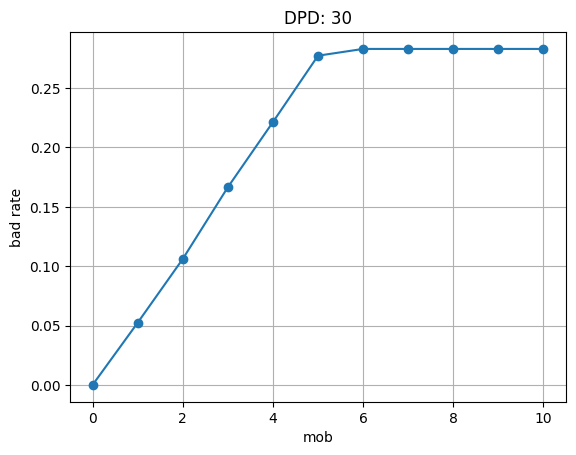

In [15]:
# set dpd label definition
dpd = 30

# Path to the folder containing CSV files
folder_path = silver_loan_daily_directory

# Read all CSV files into a single DataFrame
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)

# filter only completed loans
df = df.filter(col("loan_start_date") < datetime.strptime("2024-01-01", "%Y-%m-%d"))

# create dpd flag if more than dpd
df = df.withColumn("dpd_flag", F.when(col("dpd") >= dpd, 1).otherwise(0))

# actual bads 
actual_bads_df = df.filter(col("installment_num") == 10)

# prepare for analysis
# df = df.filter(col("installment_num") < 10)

# visualise bad rate
pdf = df.toPandas()

# Group by col_A and count occurrences in col_B
grouped = pdf.groupby('mob')['dpd_flag'].mean()

# Sort the index (x-axis) of the grouped DataFrame
grouped = grouped.sort_index()

# Plotting
grouped.plot(kind='line', marker='o')

plt.title('DPD: '+ str(dpd))
plt.xlabel('mob')
plt.ylabel('bad rate')
plt.grid(True)
plt.show()


In [16]:
df.show()

+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|             loan_id|Customer_ID|loan_start_date|tenure|installment_num|loan_amt|due_amt|paid_amt|overdue_amt|balance|snapshot_date|mob|installments_missed|first_missed_date|dpd|dpd_flag|
+--------------------+-----------+---------------+------+---------------+--------+-------+--------+-----------+-------+-------------+---+-------------------+-----------------+---+--------+
|CUS_0x1011_2023_1...| CUS_0x1011|     2023-11-01|    10|             10| 10000.0| 1000.0|  1000.0|        0.0|    0.0|   2024-09-01| 10|                  0|             NULL|  0|       0|
|CUS_0x1013_2023_1...| CUS_0x1013|     2023-12-01|    10|              9| 10000.0| 1000.0|  1000.0|        0.0| 1000.0|   2024-09-01|  9|                  0|             NULL|  0|       0|
|CUS_0x1018_2023_1...| CUS_0x1018|     2023-11-01|    1

## EDA on feature table

In [17]:
# load silver feature table for one date to inspect
df = spark.read.parquet("datamart/silver/features/silver_feature_store_2023_01_01.parquet")

# check nulls
null_counts = df.select([F.count(F.when(F.col(c).isNull(), c)).alias(c) for c in df.columns])
null_df = null_counts.toPandas().T.reset_index()
null_df.columns = ["column", "null_count"]
display(null_df)

,column,null_count
0,Customer_ID,0
1,snapshot_date,0
2,Age,22
3,Occupation,0
4,Annual_Income,45
5,Monthly_Inhand_Salary,0
6,Num_Bank_Accounts,0
7,Num_Credit_Card,0
8,Interest_Rate,0
9,Num_of_Loan,39


In [18]:
# check basic stats
display(df.describe().toPandas().set_index("summary").T)

summary,count,mean,stddev,min,max
Customer_ID,530,None,None,CUS_0x1037,CUS_0xfc9
Age,508,114.40748031496064,785.7811282801916,-500,8547
Occupation,530,None,None,Accountant,_______
Annual_Income,485,131447.22954252578,1016996.0210091638,7110.93,1.7706148E7
Monthly_Inhand_Salary,530,4206.805633429762,3067.671196223315,368.37418,14601.52
Num_Bank_Accounts,530,14.554716981132076,101.87965873660202,0,1605
Num_Credit_Card,530,15.147169811320754,82.21322410006572,1,896
Interest_Rate,530,85.76603773584905,527.7946681227713,1.0,5059.0
Num_of_Loan,491,0.04684317718940937,42.52792414227231,-100,777
Type_of_Loan,446,None,None,Auto Loan,"Student Loan, and Personal Loan"


In [19]:
# check categorical value and null counts
df.groupBy("Occupation").count().orderBy("count", ascending=False).show()
df.groupBy("Credit_Mix").count().orderBy("count", ascending=False).show()
df.groupBy("Payment_Behaviour").count().orderBy("count", ascending=False).show()
df.groupBy("Type_of_Loan").count().orderBy("count", ascending=False).show()
df.groupBy("Age").count().orderBy("count", ascending=False).show()
df.groupBy("Annual_Income").count().orderBy("count", ascending=False).show()
df.groupBy("Num_of_Loan").count().orderBy("count", ascending=False).show()
df.groupBy("Num_of_Delayed_Payment").count().orderBy("count", ascending=False).show()
df.groupBy("Annual_Income").count().orderBy("count", ascending=False).show()
df.groupBy("Outstanding_Debt").count().orderBy("count", ascending=False).show()
df.groupBy("Amount_invested_monthly").count().orderBy("count", ascending=False).show()

+-------------+-----+
|   Occupation|count|
+-------------+-----+
|   Journalist|   45|
|       Lawyer|   40|
|Media_Manager|   39|
|       Writer|   39|
|      _______|   38|
|    Developer|   36|
|    Scientist|   35|
|       Doctor|   33|
|   Accountant|   33|
|     Musician|   31|
|     Engineer|   30|
|     Mechanic|   29|
|      Teacher|   28|
|    Architect|   27|
| Entrepreneur|   27|
|      Manager|   20|
+-------------+-----+

+----------+-----+
|Credit_Mix|count|
+----------+-----+
|  Standard|  205|
|      Good|  132|
|         _|  110|
|       Bad|   83|
+----------+-----+

+--------------------+-----+
|   Payment_Behaviour|count|
+--------------------+-----+
|Low_spent_Small_v...|  144|
|High_spent_Medium...|  106|
|High_spent_Large_...|   77|
|Low_spent_Medium_...|   71|
|High_spent_Small_...|   49|
|Low_spent_Large_v...|   45|
|              !@9#%8|   38|
+--------------------+-----+

+--------------------+-----+
|        Type_of_Loan|count|
+--------------------+-----+

+-----------+-----+
|Num_of_Loan|count|
+-----------+-----+
|          2|   76|
|          3|   75|
|          0|   71|
|          4|   67|
|          1|   46|
|       NULL|   39|
|          6|   39|
|          5|   33|
|          7|   28|
|       -100|   25|
|          9|   14|
|          8|   14|
|        103|    1|
|        777|    1|
|        119|    1|
+-----------+-----+

+----------------------+-----+
|Num_of_Delayed_Payment|count|
+----------------------+-----+
|                    12|   37|
|                    17|   36|
|                     9|   35|
|                     8|   32|
|                    18|   32|
|                    15|   31|
|                    16|   30|
|                    14|   30|
|                    19|   26|
|                    20|   23|
|                    11|   23|
|                    10|   22|
|                    13|   17|
|                     7|   15|
|                    22|   14|
|                  NULL|   14|
|                    23|   14|

## Build gold table for labels

In [20]:
# create gold datalake
gold_label_store_directory = "datamart/gold/label_store/"

if not os.path.exists(gold_label_store_directory):
    os.makedirs(gold_label_store_directory)

In [21]:
# run gold backfill
for date_str in dates_str_lst:
    utils.data_processing_gold_lms_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd = 30, mob = 6)


loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_01_01.parquet row count: 530


saved to: datamart/gold/label_store/gold_label_store_2023_01_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_02_01.parquet row count: 1031


saved to: datamart/gold/label_store/gold_label_store_2023_02_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_03_01.parquet row count: 1537


saved to: datamart/gold/label_store/gold_label_store_2023_03_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_04_01.parquet row count: 2047


saved to: datamart/gold/label_store/gold_label_store_2023_04_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2023_05_01.parquet row count: 2568


...

saved to: datamart/gold/label_store/gold_label_store_2024_07_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_08_01.parquet row count: 5531


saved to: datamart/gold/label_store/gold_label_store_2024_08_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_09_01.parquet row count: 5537
saved to: datamart/gold/label_store/gold_label_store_2024_09_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_10_01.parquet row count: 5502


saved to: datamart/gold/label_store/gold_label_store_2024_10_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_11_01.parquet row count: 5501


saved to: datamart/gold/label_store/gold_label_store_2024_11_01.parquet
loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet row count: 5531


saved to: datamart/gold/label_store/gold_label_store_2024_12_01.parquet


In [22]:
utils.data_processing_gold_lms_table.process_labels_gold_table(date_str, silver_loan_daily_directory, gold_label_store_directory, spark, dpd = 30, mob = 6).dtypes


loaded from: datamart/silver/loan_daily/silver_loan_daily_2024_12_01.parquet row count: 5531


saved to: datamart/gold/label_store/gold_label_store_2024_12_01.parquet


[('loan_id', 'string'),
 ('Customer_ID', 'string'),
 ('label', 'int'),
 ('label_def', 'string'),
 ('snapshot_date', 'date')]

## inspect label store

In [23]:
folder_path = gold_label_store_directory
files_list = [folder_path+os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
print("row_count:",df.count())

df.show()

row_count: 8974
+--------------------+-----------+-----+----------+-------------+
|             loan_id|Customer_ID|label| label_def|snapshot_date|
+--------------------+-----------+-----+----------+-------------+
|CUS_0x1037_2023_0...| CUS_0x1037|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1069_2023_0...| CUS_0x1069|    0|30dpd_6mob|   2023-07-01|
|CUS_0x114a_2023_0...| CUS_0x114a|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1184_2023_0...| CUS_0x1184|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1297_2023_0...| CUS_0x1297|    1|30dpd_6mob|   2023-07-01|
|CUS_0x12fb_2023_0...| CUS_0x12fb|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1325_2023_0...| CUS_0x1325|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1341_2023_0...| CUS_0x1341|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1375_2023_0...| CUS_0x1375|    1|30dpd_6mob|   2023-07-01|
|CUS_0x13a8_2023_0...| CUS_0x13a8|    0|30dpd_6mob|   2023-07-01|
|CUS_0x13ef_2023_0...| CUS_0x13ef|    0|30dpd_6mob|   2023-07-01|
|CUS_0x1440_2023_0...| CUS_0x1440|    0|30dpd_6mob|   2023-0

In [24]:
df.printSchema()

root
 |-- loan_id: string (nullable = true)
 |-- Customer_ID: string (nullable = true)
 |-- label: integer (nullable = true)
 |-- label_def: string (nullable = true)
 |-- snapshot_date: date (nullable = true)



## Build gold for feature store

In [25]:
# create gold datalake
gold_feature_store_directory = "datamart/gold/feature_store/"

if not os.path.exists(gold_feature_store_directory):
    os.makedirs(gold_feature_store_directory)

In [26]:
# run gold backfill
for date_str in dates_str_lst:
    utils.data_processing_gold_feature_table.process_feature_gold_table(date_str, silver_features_directory, gold_feature_store_directory, spark)

loaded from: datamart/silver/features/silver_feature_store_2023_01_01.parquet row count: 530


saved to: datamart/gold/feature_store/gold_feature_store_2023_01_01.parquet
loaded from: datamart/silver/features/silver_feature_store_2023_02_01.parquet row count: 501


saved to: datamart/gold/feature_store/gold_feature_store_2023_02_01.parquet
loaded from: datamart/silver/features/silver_feature_store_2023_03_01.parquet row count: 506


saved to: datamart/gold/feature_store/gold_feature_store_2023_03_01.parquet
loaded from: datamart/silver/features/silver_feature_store_2023_04_01.parquet row count: 510


saved to: datamart/gold/feature_store/gold_feature_store_2023_04_01.parquet
loaded from: datamart/silver/features/silver_feature_store_2023_05_01.parquet row count: 521
saved to: datamart/gold/feature_store/gold_feature_store_2023_05_01.parquet
loaded from: datamart/silver/features/silver_feature_store_2023_06_01.parquet row count: 517


...

saved to: datamart/gold/feature_store/gold_feature_store_2024_07_01.parquet
loaded from: datamart/silver/features/silver_feature_store_2024_08_01.parquet row count: 543


saved to: datamart/gold/feature_store/gold_feature_store_2024_08_01.parquet
loaded from: datamart/silver/features/silver_feature_store_2024_09_01.parquet row count: 493


saved to: datamart/gold/feature_store/gold_feature_store_2024_09_01.parquet
loaded from: datamart/silver/features/silver_feature_store_2024_10_01.parquet row count: 456


saved to: datamart/gold/feature_store/gold_feature_store_2024_10_01.parquet
loaded from: datamart/silver/features/silver_feature_store_2024_11_01.parquet row count: 488


saved to: datamart/gold/feature_store/gold_feature_store_2024_11_01.parquet
loaded from: datamart/silver/features/silver_feature_store_2024_12_01.parquet row count: 515
saved to: datamart/gold/feature_store/gold_feature_store_2024_12_01.parquet


## inspect feature table

In [27]:
folder_path = gold_feature_store_directory
files_list = [folder_path + os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df = spark.read.option("header", "true").parquet(*files_list)
print("row_count:", df.count())
display(df.toPandas())

row_count: 11974


,Customer_ID,snapshot_date,Age,Annual_Income,Monthly_Inhand_Salary,Num_Bank_Accounts,Num_Credit_Card,Interest_Rate,Num_of_Loan,Delay_from_due_date,...,fe_16,fe_17,fe_18,fe_19,fe_20,Credit_History_Months,Occupation_encoded,Credit_Mix_encoded,Payment_Behaviour_encoded,Payment_of_Min_Amount_encoded
0,CUS_0x1037,2023-01-01,45,15989.084961,1086.423706,5,4,2.0,4,13,...,114.0,35.0,85.0,-73.0,76.0,237,7.0,1.0,0.0,1.0
1,CUS_0x1069,2023-01-01,32,58637.339844,4799.444824,4,6,10.0,119,9,...,35.0,130.0,94.0,111.0,75.0,368,7.0,0.0,4.0,0.0
2,CUS_0x114a,2023-01-01,43,15305.459961,1230.454956,0,7,2.0,2,14,...,125.0,-130.0,354.0,17.0,302.0,189,5.0,1.0,0.0,1.0
3,CUS_0x1184,2023-01-01,49,19867.474609,1396.622925,3,5,11.0,3,10,...,163.0,37.0,207.0,180.0,118.0,392,1.0,1.0,0.0,1.0
4,CUS_0x1297,2023-01-01,46,40009.738281,4881.504883,9,8,30.0,9,61,...,159.0,-26.0,104.0,118.0,184.0,164,15.0,2.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11969,CUS_0xd50,2024-10-01,41,43771.851562,3600.654053,4,3,9.0,1,18,...,NaN,NaN,NaN,NaN,NaN,309,9.0,1.0,2.0,1.0
11970,CUS_0xde4,2024-10-01,30,75402.523438,6221.543457,2,4,3.0,3,0,...,NaN,NaN,NaN,NaN,NaN,337,1.0,1.0,0.0,1.0
11971,CUS_0xe16,2024-10-01,18,37976.679688,2997.723389,9,9,18.0,7,56,...,NaN,NaN,NaN,NaN,NaN,106,15.0,2.0,2.0,0.0
11972,CUS_0xe7a,2024-10-01,32,7711.970215,395.664154,10,5,29.0,7,57,...,NaN,NaN,NaN,NaN,NaN,11,10.0,2.0,0.0,0.0


In [28]:
df.printSchema()

root
 |-- Customer_ID: string (nullable = true)
 |-- snapshot_date: date (nullable = true)
 |-- Age: integer (nullable = true)
 |-- Annual_Income: float (nullable = true)
 |-- Monthly_Inhand_Salary: float (nullable = true)
 |-- Num_Bank_Accounts: integer (nullable = true)
 |-- Num_Credit_Card: integer (nullable = true)
 |-- Interest_Rate: float (nullable = true)
 |-- Num_of_Loan: integer (nullable = true)
 |-- Delay_from_due_date: integer (nullable = true)
 |-- Num_of_Delayed_Payment: integer (nullable = true)
 |-- Changed_Credit_Limit: float (nullable = true)
 |-- Num_Credit_Inquiries: float (nullable = true)
 |-- Outstanding_Debt: float (nullable = true)
 |-- Credit_Utilization_Ratio: float (nullable = true)
 |-- Total_EMI_per_month: float (nullable = true)
 |-- Amount_invested_monthly: float (nullable = true)
 |-- Monthly_Balance: float (nullable = true)
 |-- fe_1: integer (nullable = true)
 |-- fe_2: integer (nullable = true)
 |-- fe_3: integer (nullable = true)
 |-- fe_4: integer 

In [29]:
folder_path = gold_label_store_directory
files_list = [folder_path + os.path.basename(f) for f in glob.glob(os.path.join(folder_path, '*'))]
df_labels = spark.read.option("header", "true").parquet(*files_list)
df_labels.groupBy("snapshot_date").count().orderBy("snapshot_date").show(30)

[Stage 2592:>                                                     (0 + 12) / 12]

+-------------+-----+
|snapshot_date|count|
+-------------+-----+
|   2023-07-01|  530|
|   2023-08-01|  501|
|   2023-09-01|  506|
|   2023-10-01|  510|
|   2023-11-01|  521|
|   2023-12-01|  517|
|   2024-01-01|  471|
|   2024-02-01|  481|
|   2024-03-01|  454|
|   2024-04-01|  487|
|   2024-05-01|  491|
|   2024-06-01|  489|
|   2024-07-01|  485|
|   2024-08-01|  518|
|   2024-09-01|  511|
|   2024-10-01|  513|
|   2024-11-01|  491|
|   2024-12-01|  498|
+-------------+-----+

